In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
pca_data_abck = pd.read_csv('pca_data_abck.csv')
pca_data_abck.head()

data_fixed = pd.read_csv('data_fixed.csv')
data_fixed.head()

,cadmio,cobre,coliformes_termotolerantes,coliformes_totales,cromo,dbo5,dqo,hierro,manganeso,niquel,ph,plomo,solidos_suspendidos,solidos_totales,zinc,fecha,referencia
0,0.5,1.00,3.0,3.0,2.0,0.68,11.81,1.883,0.05285,4.0,8.20,10.0,41.0,313.0,0.13530,04/06/2001,P1
1,0.5,1.00,2.2,7.0,2.0,0.18,23.42,5.179,0.16410,4.0,8.36,10.0,185.0,453.0,0.09056,04/06/2001,P2
2,0.5,1.00,7.0,1.7,2.0,0.48,19.68,6.043,0.20470,4.0,8.47,10.0,209.0,470.0,0.09999,04/06/2001,P3
3,0.5,1.00,1.1,1.1,2.0,0.58,7.87,3.159,0.09761,4.0,8.34,10.0,74.0,350.0,0.09698,04/06/2001,P4
4,0.5,2.89,1.3,1.3,2.0,0.35,7.75,1.093,0.03675,5.2,8.44,10.0,0.0,293.0,0.11720,04/07/2001,P1


In [3]:
data_fixed["cluster"] = pca_data_abck['cluster_hibrido'].copy()
data_fixed.head()

,cadmio,cobre,coliformes_termotolerantes,coliformes_totales,cromo,dbo5,dqo,hierro,manganeso,niquel,ph,plomo,solidos_suspendidos,solidos_totales,zinc,fecha,referencia,cluster
0,0.5,1.00,3.0,3.0,2.0,0.68,11.81,1.883,0.05285,4.0,8.20,10.0,41.0,313.0,0.13530,04/06/2001,P1,0
1,0.5,1.00,2.2,7.0,2.0,0.18,23.42,5.179,0.16410,4.0,8.36,10.0,185.0,453.0,0.09056,04/06/2001,P2,0
2,0.5,1.00,7.0,1.7,2.0,0.48,19.68,6.043,0.20470,4.0,8.47,10.0,209.0,470.0,0.09999,04/06/2001,P3,3
3,0.5,1.00,1.1,1.1,2.0,0.58,7.87,3.159,0.09761,4.0,8.34,10.0,74.0,350.0,0.09698,04/06/2001,P4,0
4,0.5,2.89,1.3,1.3,2.0,0.35,7.75,1.093,0.03675,5.2,8.44,10.0,0.0,293.0,0.11720,04/07/2001,P1,0


In [7]:
# Calcular el perfil químico de cada cluster
perfil_quimico = data_fixed.drop(columns=['fecha', 'referencia']).groupby('cluster').mean()
perfil_quimico['frequencia'] = data_fixed.groupby('cluster').size()
display(perfil_quimico)

,cadmio,cobre,coliformes_termotolerantes,coliformes_totales,cromo,dbo5,dqo,hierro,manganeso,niquel,ph,plomo,solidos_suspendidos,solidos_totales,zinc,frequencia
cluster,,,,,,,,,,,,,,,,
0,10.971647,17.922290,2.266866,3.395545,42.163258,12.137942,32.368803,5.492311,0.288808,68.770574,8.060028,59.654126,69.193164,406.465818,0.143247,213
1,6.700000,29.000000,2.300000,7.000000,82.800000,3.525000,7.143000,8.050000,0.680000,170.600000,8.330000,77.300000,284.000000,11.444000,332.000000,1
2,10.000000,130.020000,4.800000,4.540000,290.730000,11.000000,26.603000,68.222000,13.662000,355.080000,7.320000,50.710000,680.000000,13710.000000,1.189100,1
3,13.083704,20.547143,6.590926,3.925000,66.553315,13.858889,24.195267,5.374291,0.352986,98.292500,8.154778,68.407037,104.064259,377.647485,0.329705,108
4,24.833333,450.200000,4.496667,3.546667,442.218333,24.238833,12.789167,33.774000,3.725233,414.270000,8.093333,82.876667,311.411667,53.845333,1.061383,6
5,24.755297,75.347657,3.745405,4.124054,326.458422,22.419654,30.759149,71.483768,7.924762,398.158622,7.415676,200.311324,380.070319,115.367508,3.053390,74
6,106.024000,94.390000,2.545333,4.842667,513.540933,31.796400,53.426987,116.338267,45.484133,27.398360,6.386133,262.220747,117.844827,96.065187,6.196645,15
7,11.496000,39.782281,3.787027,4.325405,306.776486,488.160811,3.943211,7.526216,0.591838,291.630124,8.348757,77.775622,185.285557,137.688005,0.649753,37
8,13.484333,73.641917,3.165444,3.523556,499.893578,16.801006,11.804699,19.084401,1.645345,385.680350,8.082922,77.624354,347.754886,50.567758,1.703018,180


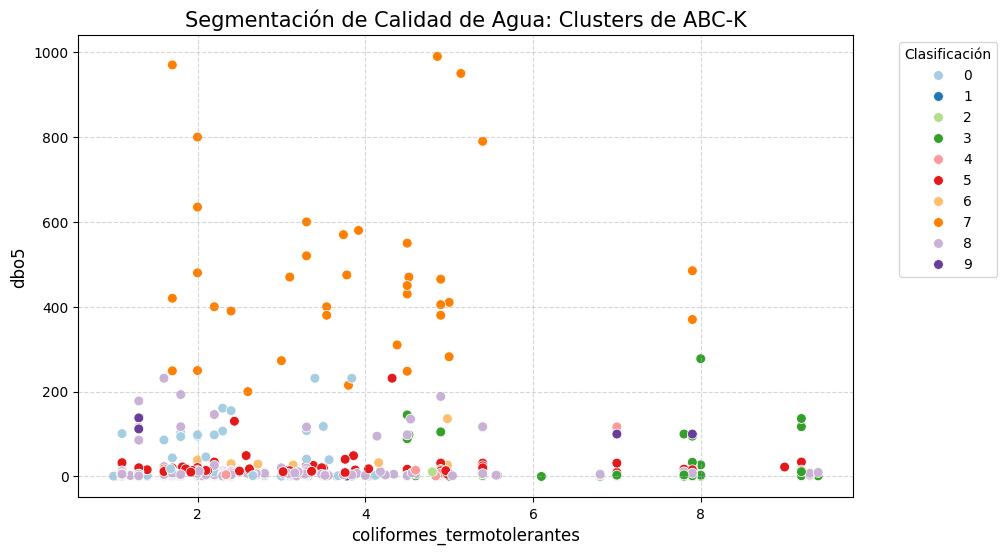

In [11]:
# data_fixed.plot(kind='scatter', x="cadmio", y='cobre', c='cluster', colormap='seismic', legend=True)

pca_labels = ['coliformes_termotolerantes', 'dbo5']

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=data_fixed, 
    x=pca_labels[0], 
    y=pca_labels[1], 
    hue='cluster', 
    palette='Paired', 
    s=50, 
    alpha=1,
    edgecolor='w'
)

# Personalización de títulos (basado en tu interpretación de loadings)
plt.title('Segmentación de Calidad de Agua: Clusters de ABC-K', fontsize=15)
plt.xlabel(f'{pca_labels[0]}', fontsize=12)
plt.ylabel(f'{pca_labels[1]}', fontsize=12)
plt.legend(title='Clasificación', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.50)
plt.show()
